# AR segmentation: fine-tuning Surya

This notebook mirrors `template/2_finetune_template_1D.ipynb`. It replaces the baseline's
14-parameter model with the Surya backbone plus a 2D head, loads the pretrained weights, adds
LoRA adapters, and trains with the **same dataset, metrics and Lightning module** as
`1_baseline_ar.ipynb`. **_The two notebooks are on purpose almost identical._**

Memory note: one 13x4096x4096 sample plus the 366 M-parameter backbone needs a large GPU
(the training script uses `bf16-mixed` and gradient checkpointing on every block). Keep
`batch_size: 1`.

## Set your cuda visible device

**IMPORTANT:** Since we are sharing resources, please make sure that the cuda visible device you put here is the one assigned to your team and your machine.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Must be set BEFORE torch is imported: cuBLAS reads this once, when it initializes, so
# setting it later has no effect. (Restart the kernel if torch was already imported.)
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import sys
import numpy as np
import matplotlib.pyplot as plt
import torch

# Gives the notebook access to workshop_infrastructure/ and downstream_apps/.
sys.path.append("../../")

from workshop_infrastructure.utils import build_scalers  # per-channel normalization stats

torch.set_float32_matmul_precision("medium")

In [3]:
import lightning as L
from workshop_infrastructure.utils import apply_peft_lora, load_pretrained_weights

## Load configuration

The config is the single source of truth. `load_ar_config()` parses `configs/config_script.yaml`
into a typed object, exactly as `finetune_ar_segmentation.py` does, so the same YAML behaves
identically here and in the script.

The `data:` section is parsed into `ARDataConfig` (see `configs.py`), which adds the AR-specific
keys on top of the shared `DataConfig`:

| key | meaning |
|---|---|
| `ar_mask_dir` | directory with the split CSVs and `data/YYYY/MM/*.h5` masks |
| `ar_mask_splits` | which mask CSVs to load (the Surya index decides train vs validation) |
| `ar_mask_key` | `union_with_intersect` (AR footprints) or `intersection` (the PILs) |
| `ar_pooling` | block-mean pooling of inputs and mask; 1 = native 4096x4096 |
| `ar_pos_weight` | up-weights AR pixels in the BCE loss (they are ~1.3 % of the disk) |
| `ar_threshold` | probability cut for IoU / Dice / precision / recall |

`AR_CONFIG` lets you point at a different YAML (for example one with local indices) without
editing the notebook.

In [4]:
from downstream_apps.ar_segmentation.configs import load_ar_config

config_path = os.environ.get("AR_CONFIG", "./configs/config_script.yaml")
cfg = load_ar_config(config_path)
print(f"Loaded config for job: {cfg.job_id}")
print(f"  train index : {cfg.data.train_data_path}")
print(f"  masks       : {cfg.data.ar_mask_dir}  (key: {cfg.data.ar_mask_key})")
print(f"  s3 cache    : {cfg.data.s3_cache_dir}")

Loaded config for job: ar_segmentation_baseline
  train index : /home/jovyan/surya_workshop/data/indices/surya_aws_s3_train.csv
  masks       : /home/jovyan/scratch_space/AR_Seg_Uncertainty/data/assets/surya-bench-ar-segmentation  (key: union_with_intersect)
  s3 cache    : /home/jovyan/.cache/surya_workshop/helio_s3_cache


## Download assets

`ensure_assets()` fetches only what is missing from HuggingFace, so re-running this is free.
The AR masks are a separate dataset; fetch them once with `bash download_masks.sh` (about
1.3 GB, no login needed). The SDO inputs stream from the public `nasa-surya-bench` S3 bucket,
which needs a local cache directory: set `SURYA_WS_CACHE_DIR` or `data.s3_cache_dir`
(budget roughly 1 GB per unique timestep).

In [5]:
from workshop_infrastructure.assets import ensure_assets

ensure_assets(cfg, which=['scalers', 'weights'])

scalers = build_scalers(info=cfg.data.scalers_path)
print(f"Loaded scalers for {len(scalers)} channels.")

[assets] surya.366m.v1.pt not found — downloading from nasa-ibm-ai4science/Surya-1.0 ...


surya.366m.v1.pt:   0%|          | 0.00/1.80G [00:00<?, ?B/s]

[assets] Saved to /home/jovyan/surya_workshop/downstream_apps/ar_segmentation/assets/surya.366m.v1.pt
Loaded scalers for 13 channels.


## Define the datasets and dataloaders

`build_helio_dataloaders()` constructs the train and validation datasets and wraps them in
DataLoaders. It fills in every generic argument from the config; only the AR-specific arguments
are passed here, and they are the same list `finetune_ar_segmentation.py` passes.

The validation set gets `phase="val"` and is not shuffled.

In [6]:
from downstream_apps.ar_segmentation.datasets.ar_dataset import ARSegmentationDataset
from workshop_infrastructure.datasets.builders import build_helio_dataloaders

train_data_loader, val_data_loader = build_helio_dataloaders(
    cfg,
    ARSegmentationDataset,
    scalers=scalers,
    num_workers=2,          # fewer workers than the script: notebooks start faster
    #### Downstream (DS) specific parameters
    return_surya_stack=True,
    max_number_of_samples=cfg.data.max_samples,
    ds_mask_dir=cfg.data.ar_mask_dir,
    ds_mask_splits=cfg.data.ar_mask_splits,
    ds_mask_key=cfg.data.ar_mask_key,
    pooling=cfg.data.ar_pooling,
)

batch_size = cfg.batch_size
print(f"train: {len(train_data_loader.dataset)} samples | "
      f"val: {len(val_data_loader.dataset)} samples | batch_size: {batch_size}")

train: 10 samples | val: 10 samples | batch_size: 1


In [7]:
batch = next(iter(train_data_loader))
print({k: (tuple(v.shape) if hasattr(v, "shape") else type(v).__name__) for k, v in batch.items()})

{'ts': (1, 13, 1, 4096, 4096), 'time_delta_input': (1, 1), 'forecast': (1, 4096, 4096), 'ds_index': 'list'}


## Initialize the HelioSpectformer model

This is the main difference from the baseline notebook. AR segmentation is a **2D** task: the
output has the same height and width as the input. So instead of `HelioSpectformer1D` (which
pools the tokens into a vector) we use `HelioSpectformer2D`, which keeps the Surya backbone and
adds `head_unembed`, a linear projection from each 16x16-patch token back to pixels with
`ft_out_chans=1` output channel of logits.

The head's `head_` prefix is not cosmetic: `apply_peft_lora()` discovers head modules by that
prefix and keeps them trainable. Without it the adapters would fit a frozen random readout.

Because the head is linear per patch, predictions are piecewise-linear at 16-pixel granularity.
Expect blocky region boundaries; that is an architectural floor, not a data problem.

In [8]:
from workshop_infrastructure.models.finetune_models import HelioSpectformer2D

_DTYPES = {"float32": torch.float32, "bfloat16": torch.bfloat16, "float16": torch.float16}

model = HelioSpectformer2D.from_config(
    cfg.model,
    dtype=_DTYPES[cfg.dtype] if isinstance(cfg.dtype, str) else cfg.dtype,
    use_latitude_in_learned_flow=cfg.use_latitude_in_learned_flow,
    ft_unembedding_type="linear",
    ft_out_chans=1,
)

/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Load the pretrained weights

The checkpoint was saved from `HelioSpectFormer` directly, so its keys are flat, while the
fine-tuning model nests the backbone under `backbone.*`. `load_pretrained_weights()` tries both
spellings, skips shape mismatches, and reports how many tensors matched. A low count means the
architecture in the config does not match the checkpoint.

In [9]:
load_pretrained_weights(model, cfg.model.pretrained_path)

Loading pretrained weights from /home/jovyan/surya_workshop/downstream_apps/ar_segmentation/assets/surya.366m.v1.pt.


Loaded 156 / 159 pretrained weights.


## To LoRA or not to LoRA

Three regimes, all selected from the `model:` section of the config:

| `use_lora` | `freeze_backbone` | regime | trains |
|---|---|---|---|
| `true` | ignored | LoRA adapters + the whole head (default) | ~3 M |
| `false` | `true` | linear probe: only `head_unembed` | the head |
| `false` | `false` | full fine-tuning | all 366 M |

Adapters go on `fc1`/`fc2` in all ten blocks and on `attn.qkv`/`attn.proj` in the eight
attention blocks. The printout below lists exactly which modules were adapted and which head
modules stay trainable. Check it: a misspelt `target_modules` entry is silently ignored by PEFT.

In [10]:
if cfg.model.freeze_backbone:
    for name, param in model.named_parameters():
        if name.startswith("backbone."):
            param.requires_grad = False

if cfg.model.use_lora:
    model = apply_peft_lora(model, cfg.model.lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

Applying PEFT LoRA: r=8, alpha=8, dropout=0.1, modules=['fc1', 'fc2', 'attn.qkv', 'attn.proj']


trainable params: 1,515,520 || all params: 359,510,528 || trainable%: 0.42%
Trainable parameters: 1,515,520 / 359,510,528 (0.42%)


Test the forward pass on one batch. The output is [B, 1, H, W] logits, the same contract as the
baseline, so the metrics and the Lightning module need no changes. The untrained head makes the
values meaningless; this is a shape check.

In [11]:
with torch.no_grad():
    output = model(batch)
print("input ts:", tuple(batch["ts"].shape), "->", "logits:", tuple(output.shape))

input ts: (1, 13, 1, 4096, 4096) -> logits: (1, 1, 4096, 4096)


## Define your metrics

`ARMetrics` (in `metrics/ar_metrics.py`) follows the template's four-mode contract:

| mode | what | backpropagates |
|---|---|---|
| `train_loss` | binary cross-entropy with logits, optional `pos_weight` | yes |
| `val_loss` | same BCE; **this is what `ModelCheckpoint` monitors** | no |
| `train_metrics` | empty on purpose (IoU over 16.8 M pixels per step is not worth it) | no |
| `val_metrics` | IoU, Dice, precision, recall at `ar_threshold`, and the AR pixel fraction | no |

Metrics are pooled over all pixels in the batch. A batch with an empty mask and an empty
prediction scores IoU 1: predicting nothing on a quiet Sun is correct.

**This is the class both the baseline and Surya are scored with.** That is what makes the
comparison between the two meaningful.

In [12]:
from downstream_apps.ar_segmentation.metrics.ar_metrics import ARMetrics

metric_kwargs = dict(threshold=cfg.data.ar_threshold, pos_weight=cfg.data.ar_pos_weight)
train_loss_metrics = ARMetrics("train_loss", **metric_kwargs)
val_loss_metrics = ARMetrics("val_loss", **metric_kwargs)
train_evaluation_metrics = ARMetrics("train_metrics", **metric_kwargs)
validation_evaluation_metrics = ARMetrics("val_metrics", **metric_kwargs)

Evaluate them on the untrained model's output. The target gets a channel axis, exactly as the
Lightning module does, so it matches the [B, 1, H, W] output. The loss should sit near
`log(2) = 0.69`, and IoU near the AR fraction: a random model is about as good as guessing.

In [13]:
target = batch["forecast"].unsqueeze(1).float()
print("train loss:", {k: round(v.item(), 4) for k, v in train_loss_metrics(output, target)[0].items()})
print("val metrics:", {k: round(v.item(), 4) for k, v in validation_evaluation_metrics(output, target)[0].items()})

train loss: {'bce': 0.7079}


val metrics: {'iou': 0.0003, 'dice': 0.0006, 'precision': 0.0003, 'recall': 0.5089, 'pos_frac': 0.0003}


## The PyTorch Lightning module

The template's Lightning module is task-agnostic: it calls the model on the batch, computes the
metrics on `(output, batch["forecast"].unsqueeze(1))` and logs them. It is reused here under the
name `SegmentationLightningModule` (see `lightning_modules/pl_segmentation.py`).

**_It is the same module for the baseline and for Surya._**

In [14]:
from downstream_apps.ar_segmentation.lightning_modules.pl_segmentation import SegmentationLightningModule

## Set your global seeds

In [15]:
L.seed_everything(cfg.seed, workers=True)

Seed set to 42


42

## Initialize the Lightning module

No `preprocess_fn` here: Surya consumes the normalized inputs directly.

In [16]:
metrics = {
    "train_loss": train_loss_metrics,
    "val_loss": val_loss_metrics,
    "train_metrics": train_evaluation_metrics,
    "val_metrics": validation_evaluation_metrics,
}

lit_model = SegmentationLightningModule(model, metrics, lr=cfg.learning_rate, batch_size=batch_size)

## Logging

Set `use_wandb = True` to log to Weights and Biases in addition to the CSV logger. The first
run on a machine asks you to log in. The CSV logger writes `runs/<project>/version_N/metrics.csv`,
which is enough for the comparisons in this exercise.

In [17]:
from lightning.pytorch.loggers import CSVLogger, WandbLogger

use_wandb = False
project_name = cfg.wandb_project
run_name = "ar_finetune_experiment_1"

loggers = [CSVLogger("runs", name=project_name)]
if use_wandb:
    loggers.append(WandbLogger(entity=cfg.wandb_entity, project=project_name, name=run_name,
                               log_model=False, save_dir="./wandb/wandb_tmp"))

## Initialize the trainer

Mixed precision (`bf16-mixed`) halves the activation memory of the backbone. On CPU Lightning
falls back to full precision.

In [18]:
from lightning.pytorch.callbacks import ModelCheckpoint

max_epochs = 2

trainer = L.Trainer(
    max_epochs=max_epochs,
    accelerator="auto",
    devices="auto",
    precision="bf16-mixed" if torch.cuda.is_available() else "32-true",
    logger=loggers,
    callbacks=[ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)],
    log_every_n_steps=2,
)

Using bfloat16 Automatic Mixed Precision (AMP)


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Fit the model

In [19]:
trainer.fit(lit_model, train_data_loader, val_data_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/home/jovyan/envs/surya_ws/lib/python3.12/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type      | Params | Mode  | FLOPs
----------------------------------------------------
0 | model | PeftModel | 359 M  | train | 0    
----------------------------------------------------
1.5 M     Trainable params
357 M     Non-trainable params
359 M     Total params
1,438.042 Total estimated model params size (MB)
531       Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2` reached.


## Compare with the baseline

Put the two runs side by side. The difference in `val_metric_iou` is the value the foundation
model adds over a 14-parameter pixel classifier, measured with identical data and metrics.

In [20]:
import pandas as pd

metrics_csv = os.path.join(loggers[0].log_dir, "metrics.csv")
df = pd.read_csv(metrics_csv)
val_cols = [c for c in df.columns if c.startswith("val_")]
print(df[["epoch"] + val_cols].dropna(subset=val_cols, how="all").to_string(index=False))

 epoch  val_loss  val_loss_bce  val_metric_dice  val_metric_iou  val_metric_pos_frac  val_metric_precision  val_metric_recall
     0  0.010079      0.010079         0.001142        0.000571             0.001037              0.903224           0.000571
     1  0.016197      0.016197         0.000000        0.000000             0.001037              1.000000           0.000000


## Look at a prediction

Numbers first, pictures second: plot the predicted probability map next to the mask for one
validation sample. The third panel is the thresholded prediction, which is what IoU scores.

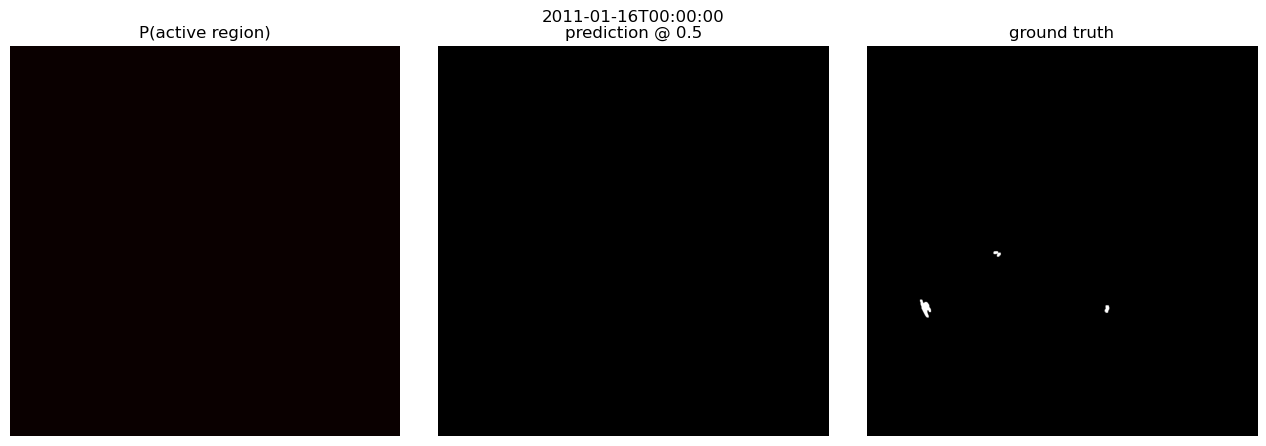

In [21]:
lit_model.eval()
val_batch = next(iter(val_data_loader))
with torch.no_grad():
    b = lit_model.preprocess_fn(val_batch) if getattr(lit_model, "preprocess_fn", None) else val_batch
    prob = torch.sigmoid(lit_model(b).float())[0, 0].cpu().numpy()
mask = val_batch["forecast"][0].numpy()

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(prob, cmap="hot", vmin=0, vmax=1); axes[0].set_title("P(active region)")
axes[1].imshow(prob >= cfg.data.ar_threshold, cmap="gray"); axes[1].set_title(f"prediction @ {cfg.data.ar_threshold}")
axes[2].imshow(mask, cmap="gray"); axes[2].set_title("ground truth")
for ax in axes:
    ax.axis("off")
plt.suptitle(val_batch["ds_index"][0])
plt.tight_layout()

## Conclusion

Dataset, metrics, baseline and Surya fine-tune now share one pipeline. From here:

- raise `max_samples` and `max_epochs` for real numbers; use `--deterministic warn` in the
  script when comparing runs;
- try `ar_pos_weight` for the class imbalance, or `ar_mask_key: intersection` to segment the
  PILs themselves;
- for longer runs use `finetune_ar_segmentation.py`, which applies exactly this notebook's
  logic with DDP and checkpoint upload.